In [1]:
import pandas as pd
import numpy as np
import pmdarima as pm
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/Merged files/csv/apple/merged_apple_funadmentals_price_macro.csv')

In [3]:
df

,quarter,period_end,Price,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
0,Q1 2010,2009-12-26,6.407192,15683000000,3378000000,2.969820,35768000000,0.11,0.120000
1,Q2 2010,2010-03-27,7.127073,13499000000,3074000000,3.221921,39348000000,1.75,0.133333
2,Q3 2010,2010-06-26,7.634115,15700000000,3253000000,2.994587,43111000000,2.91,0.193333
3,Q4 2010,2010-09-25,8.590257,20343000000,4308000000,2.744706,47791000000,3.34,0.186667
4,Q1 2011,2010-12-25,9.775751,26741000000,6004000000,2.704265,54666000000,2.78,0.186667
...,...,...,...,...,...,...,...,...,...
58,Q3 2024,2024-06-29,210.863424,85777000000,21448000000,1.251820,66708000000,3.04,5.330000
59,Q4 2024,2024-09-28,228.456772,94930000000,14736000000,1.184885,56950000000,2.72,5.263333
60,Q1 2025,2024-12-28,248.049447,124300000000,36330000000,1.240719,66758000000,2.53,4.650000
61,Q2 2025,2025-03-29,219.273273,95359000000,24780000000,1.252597,66796000000,1.99,4.330000


In [4]:
# Create a data column with exacly quarter end date and then remove "period_end" column

def quarter_to_date(qstr):
    q, year = qstr.split()
    year = int(year)
    if q == "Q1":
        return pd.Timestamp(year-1, 12, 31)  # Dec 31 previous year
    elif q == "Q2":
        return pd.Timestamp(year, 3, 31)     # Mar 31 same year
    elif q == "Q3":
        return pd.Timestamp(year, 6, 30)     # Jun 30 same year
    elif q == "Q4":
        return pd.Timestamp(year, 9, 30)     # Sep 30 same year
    else:
        return pd.NaT

df["date"] = df["quarter"].apply(quarter_to_date)

df = df.drop(columns=["period_end"])

# Reorder columns to have date as the first column
df=df[["date"] + [col for col in df.columns if col != "date"]]

In [5]:
df

,date,quarter,Price,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
0,2009-12-31,Q1 2010,6.407192,15683000000,3378000000,2.969820,35768000000,0.11,0.120000
1,2010-03-31,Q2 2010,7.127073,13499000000,3074000000,3.221921,39348000000,1.75,0.133333
2,2010-06-30,Q3 2010,7.634115,15700000000,3253000000,2.994587,43111000000,2.91,0.193333
3,2010-09-30,Q4 2010,8.590257,20343000000,4308000000,2.744706,47791000000,3.34,0.186667
4,2010-12-31,Q1 2011,9.775751,26741000000,6004000000,2.704265,54666000000,2.78,0.186667
...,...,...,...,...,...,...,...,...,...
58,2024-06-30,Q3 2024,210.863424,85777000000,21448000000,1.251820,66708000000,3.04,5.330000
59,2024-09-30,Q4 2024,228.456772,94930000000,14736000000,1.184885,56950000000,2.72,5.263333
60,2024-12-31,Q1 2025,248.049447,124300000000,36330000000,1.240719,66758000000,2.53,4.650000
61,2025-03-31,Q2 2025,219.273273,95359000000,24780000000,1.252597,66796000000,1.99,4.330000


MODELO SARIMA (1,1,1) Y=Y-1, Y-2...., X1, X2, X3,...Xn

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
 

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                   63
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -713.930
Date:                Thu, 28 Aug 2025   AIC                           1445.860
Time:                        19:55:37   BIC                           1465.004
Sample:                    12-31-2009   HQIC                          1453.376
                         - 06-30-2025                                         
Covariance Type:                  opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
revenue                   1.865e-11   4.95e-11      0.376      0.707   -7.85e-11    1.16e-10
net_income                7.767e-10   1.32e-10      5.898      0.000    5.19e-10    1.03e

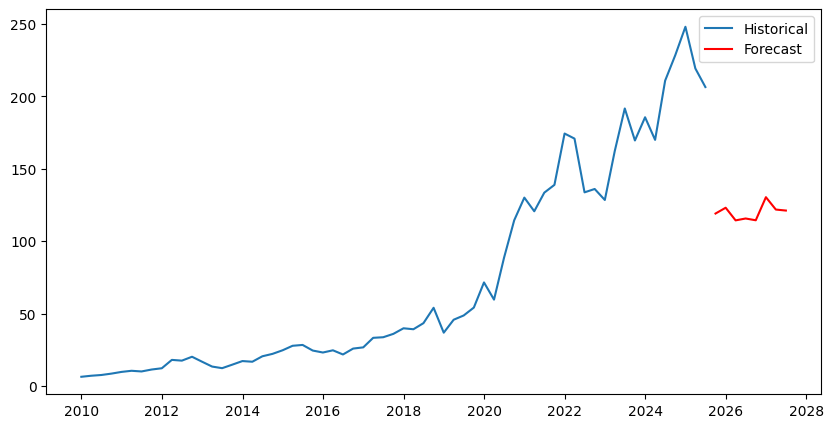

In [6]:
# Prepare data
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

y = df['Price']
X = df[['revenue', 'net_income', 'ratio assets/libailities',
        'shareholders_equity', 'gdp_growth', 'interest_rate']]

# Fit SARIMAX with exogenous regressors
model = SARIMAX(y, order=(1,1,1), exog=X)
model_fit = model.fit(disp=False)

print(model_fit.summary())

# Forecast 8 quarters ahead using the future exogenous values (X_forecast)
# For now, just reusing the last observed exog values as placeholder
X_future = X.tail(8)  

forecast = model_fit.forecast(steps=8, exog=X_future)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y, label="Historical")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.show()

In [7]:
# ===== 1) Prepare data (expects the columns you mentioned) =====
# df has: date, quarter, Price, revenue, net_income, ratio assets/libailities,
#         shareholders_equity, gdp_growth, interest_rate

# Ensure numeric types (coerce any stray strings/percents)
num_cols = ["Price","revenue","net_income","ratio assets/libailities",
            "shareholders_equity","gdp_growth","interest_rate"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows we can't use
df = df.dropna(subset=num_cols)

# Endogenous & exogenous
y = df["Price"]
X = df[["revenue","net_income","ratio assets/libailities",
        "shareholders_equity","gdp_growth","interest_rate"]]

# ===== 2) Time split (last 20% test) =====
split = int(len(df) * 0.8)
y_train, y_test = y.iloc[:split], y.iloc[split:]
X_train, X_test = X.iloc[:split], X.iloc[split:]

# ===== 3) Auto-select ARIMA order with exogenous regressors =====
auto = pm.auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=False,           # set True + m=4 if you later want quarterly seasonality (SARIMA)
    d=None,                   # let it pick differencing automatically
    stepwise=True,
    suppress_warnings=True,
    max_p=5, max_q=5,         # keep search compact; increase if needed
    information_criterion="aic"
)
print("Selected ARIMA order:", auto.order)

# ===== 4) Refit in statsmodels with the chosen order =====
order = auto.order
model = ARIMA(endog=y_train, exog=X_train, order=order)
fit = model.fit()
print(fit.summary())

# ===== 5) Forecast on the test set =====
pred = fit.predict(start=y_test.index[0], end=y_test.index[-1], exog=X_test)

# ===== 6) Metrics =====
mae  = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred)
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# (Optional) If you want in-sample fitted values:
# fitted_in_sample = fit.predict(start=y_train.index[0], end=y_train.index[-1], exog=X_train)

# (Optional) Quick plot (uncomment if running in notebook)
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12,5))
# plt.plot(y, label="Actual")
# plt.plot(pred.index, pred, label="Forecast", color="red")
# plt.axvline(y_test.index[0], color="gray", linestyle="--", label="Train/Test split")
# plt.legend(); plt.title(f"ARIMAX (order={order})"); plt.show()

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final P

Selected ARIMA order: (4, 2, 0)
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                   50
Model:                 ARIMA(4, 2, 0)   Log Likelihood                -165.293
Date:                Thu, 28 Aug 2025   AIC                            352.586
Time:                        19:56:06   BIC                            373.169
Sample:                    12-31-2009   HQIC                           360.364
                         - 03-31-2022                                         
Covariance Type:                  opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
revenue                  -6.495e-11   2.66e-10     -0.244      0.807   -5.87e-10    4.57e-10
net_income                9.249e-10   8.16e-10      1.134

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final P